In [1]:
import re
import json
from pathlib import Path
import pandas as pd

DOCS_PATH = Path("../docs/raw/docs-apim/en/docs")
OUTPUT_PATH = Path("../docs/processed")
OUTPUT_PATH.mkdir(exist_ok=True)

HIGH_VALUE_FOLDERS = [
    "get-started",
    "api-design-manage",
    "api-gateway",
    "api-security",
    "ai-gateway",
    "install-and-setup",
    "tutorials",
    "use-cases"
]

print("Ready.")

Ready.


In [8]:
def clean_markdown(text):
    """
    Remove all the noise from WSO2 markdown files.
    Preserves: headings, body text, code blocks, bullet points.
    Removes: HTML tags, template vars, image links, admonitions formatting.
    """
    
    # 1. Remove template variables like {{base_path}}
    text = re.sub(r'\{\{.*?\}\}', '', text)
    
    # 2. Remove HTML tags but keep their text content
    # e.g. <b>important</b> -> important
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 3. Remove image links entirely - no useful text content
    text = re.sub(r'!\[.*?\]\(.*?\)', '', text)
    
    # 4. Clean up admonition markers (!!!  note, !!! tip etc)
    # but keep the content inside them
    text = re.sub(r'^!!!.*$', '', text, flags=re.MULTILINE)
    
    # 5. Remove HTML comments
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    
    # 6. Remove excessive blank lines (more than 2 in a row)
    text = re.sub(r'\n{3,}', '\n\n', text)
    
    # 7. Strip leading/trailing whitespace per line
    lines = [line.rstrip() for line in text.splitlines()]
    text = '\n'.join(lines)
    
    return text.strip()


# Test it on a real file
sample_file = list((DOCS_PATH / "get-started").rglob("*.md"))[0]
raw = sample_file.read_text(encoding='utf-8', errors='ignore')
cleaned = clean_markdown(raw)

print(f"Raw length: {len(raw)} chars")
print(f"Cleaned length: {len(cleaned)} chars")
print(f"Reduction: {(1 - len(cleaned)/len(raw))*100:.1f}%")
print("\n--- Cleaned sample ---")
print(cleaned[:500])

Raw length: 8467 chars
Cleaned length: 7921 chars
Reduction: 6.4%

--- Cleaned sample ---
# Key Concepts

| **Concept**                            | **Description**                                                  |
| ---------------------------------- | ------------------------------------------------------------ |
|   API                     | An API (Application Programming Interface) is the fundamental building block of WSO2 API Manager. It is an intermediate layer that acts as a communication protocol between a consumer and a service, simplifying the consumption of the service. 


In [9]:
def split_by_paragraphs(text, max_chunk_size=1200):
    """
    Last resort splitter — when a section has no H3 headings
    and is still too long, split by paragraph boundaries.
    Tries to keep code blocks intact.
    """
    chunks = []
    current = ""
    
    # Split on double newlines (paragraph boundaries)
    paragraphs = text.split('\n\n')
    
    for para in paragraphs:
        # If adding this paragraph keeps us under limit, add it
        if len(current) + len(para) + 2 <= max_chunk_size:
            current += ('\n\n' if current else '') + para
        else:
            # Save current chunk if it has content
            if current.strip() and len(current.strip()) >= 100:
                chunks.append(current.strip())
            # Start new chunk with this paragraph
            # If single paragraph is still too long, hard split it
            if len(para) > max_chunk_size:
                words = para.split()
                sub = ""
                for word in words:
                    if len(sub) + len(word) + 1 <= max_chunk_size:
                        sub += (' ' if sub else '') + word
                    else:
                        if sub:
                            chunks.append(sub.strip())
                        sub = word
                if sub:
                    current = sub
            else:
                current = para
    
    if current.strip() and len(current.strip()) >= 100:
        chunks.append(current.strip())
    
    return chunks


def chunk_by_sections(text, file_path, min_chunk_size=100, max_chunk_size=1200):
    """
    Split a markdown document into chunks by H2 sections.
    Three-level strategy:
    1. Split by H2 headings
    2. If still too long, split by H3 headings
    3. If still too long, split by paragraphs
    """
    
    # Extract H1 title for context
    h1_match = re.search(r'^# (.+)$', text, re.MULTILINE)
    page_title = h1_match.group(1) if h1_match else Path(file_path).stem
    
    # Split by H2 headings
    sections = re.split(r'\n(?=## )', text)
    
    raw_chunks = []
    
    for section in sections:
        if not section.strip():
            continue
        
        if len(section) <= max_chunk_size:
            # Good size — keep as is
            if len(section.strip()) >= min_chunk_size:
                raw_chunks.append(section.strip())
        else:
            # Too long — try splitting by H3
            subsections = re.split(r'\n(?=### )', section)
            
            if len(subsections) > 1:
                # Has H3 headings — use them
                current = ""
                for sub in subsections:
                    if len(current) + len(sub) <= max_chunk_size:
                        current += ('\n\n' if current else '') + sub
                    else:
                        if current.strip() and len(current.strip()) >= min_chunk_size:
                            raw_chunks.append(current.strip())
                        # Sub itself might still be too long
                        if len(sub) > max_chunk_size:
                            para_chunks = split_by_paragraphs(sub, max_chunk_size)
                            raw_chunks.extend(para_chunks)
                        else:
                            current = sub
                if current.strip() and len(current.strip()) >= min_chunk_size:
                    raw_chunks.append(current.strip())
            else:
                # No H3 headings — split by paragraphs
                para_chunks = split_by_paragraphs(section, max_chunk_size)
                raw_chunks.extend(para_chunks)
    
    # Build chunk objects with metadata
    chunk_objects = []
    for i, chunk_text in enumerate(raw_chunks):
        heading_match = re.search(r'^#{1,3} (.+)$', chunk_text, re.MULTILINE)
        section_heading = heading_match.group(1) if heading_match else "General"
        
        # Get folder name cleanly
        parts = Path(file_path).parts
        folder = parts[-3] if len(parts) >= 3 else 'unknown'
        # Match against known folders
        for hv in HIGH_VALUE_FOLDERS:
            if hv in str(file_path):
                folder = hv
                break
        
        chunk_objects.append({
            'text': f"# {page_title}\n\n{chunk_text}",
            'metadata': {
                'source_file': str(file_path),
                'page_title': page_title,
                'section': section_heading,
                'folder': folder,
                'chunk_index': i,
                'char_count': len(chunk_text)
            }
        })
    
    return chunk_objects


# Test on a large file
large_files = []
for folder in HIGH_VALUE_FOLDERS:
    folder_path = DOCS_PATH / folder
    if folder_path.exists():
        for f in folder_path.rglob("*.md"):
            size = len(f.read_text(encoding='utf-8', errors='ignore'))
            if size > 5000:
                large_files.append((size, f))

large_files.sort(reverse=True)
test_file = large_files[0][1]

print(f"Testing on largest file: {test_file.name} ({large_files[0][0]} chars)")
raw = test_file.read_text(encoding='utf-8', errors='ignore')
cleaned = clean_markdown(raw)
chunks = chunk_by_sections(cleaned, test_file)

print(f"Produced {len(chunks)} chunks")
sizes = [c['metadata']['char_count'] for c in chunks]
print(f"Max chunk: {max(sizes)} chars")
print(f"Mean chunk: {sum(sizes)//len(sizes)} chars")
over_limit = sum(1 for s in sizes if s > 1200)
print(f"Over 1200 chars: {over_limit}")

Testing on largest file: security-guidelines-for-production-deployment.md (42562 chars)
Produced 33 chunks
Max chunk: 1184 chars
Mean chunk: 938 chars
Over 1200 chars: 0


In [10]:
all_chunks = []
skipped = 0

for folder in HIGH_VALUE_FOLDERS:
    folder_path = DOCS_PATH / folder
    if not folder_path.exists():
        continue
        
    files = list(folder_path.rglob("*.md"))
    print(f"Processing {folder}: {len(files)} files", end=" ")
    
    folder_chunks = 0
    for file_path in files:
        try:
            raw = file_path.read_text(encoding='utf-8', errors='ignore')
            
            # Skip very small files - likely index pages
            if len(raw) < 200:
                skipped += 1
                continue
            
            cleaned = clean_markdown(raw)
            chunks = chunk_by_sections(cleaned, file_path)
            all_chunks.extend(chunks)
            folder_chunks += len(chunks)
            
        except Exception as e:
            print(f"\n  Error on {file_path.name}: {e}")
            skipped += 1
    
    print(f"→ {folder_chunks} chunks")

print(f"\nTotal chunks: {len(all_chunks)}")
print(f"Skipped files: {skipped}")

Processing get-started: 8 files → 92 chunks
Processing api-design-manage: 79 files → 463 chunks
Processing api-gateway: 47 files → 304 chunks
Processing api-security: 53 files → 465 chunks
Processing ai-gateway: 47 files → 339 chunks
Processing install-and-setup: 84 files → 1197 chunks
Processing tutorials: 31 files → 257 chunks
Processing use-cases: 1 files → 10 chunks

Total chunks: 3127
Skipped files: 0


Chunk size statistics:
count    3127.000000
mean      794.854813
std       333.241562
min       102.000000
25%       509.500000
50%       875.000000
75%      1099.000000
max      1745.000000
Name: char_count, dtype: float64

Chunks per folder:
folder
install-and-setup    1197
api-security          465
api-design-manage     463
ai-gateway            339
api-gateway           304
tutorials             257
get-started            92
use-cases              10
Name: section, dtype: int64


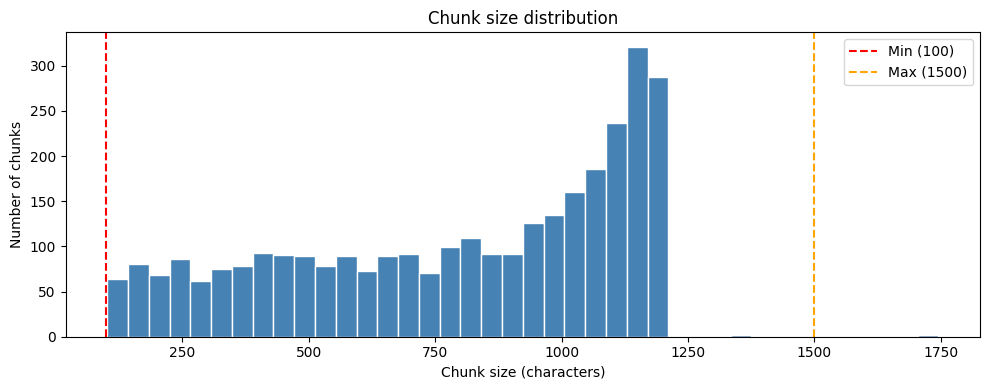

In [11]:
chunk_df = pd.DataFrame([{
    'folder': c['metadata']['folder'],
    'page_title': c['metadata']['page_title'],
    'section': c['metadata']['section'],
    'char_count': c['metadata']['char_count']
} for c in all_chunks])

print("Chunk size statistics:")
print(chunk_df['char_count'].describe())

print("\nChunks per folder:")
print(chunk_df.groupby('folder')['section'].count().sort_values(ascending=False))

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(chunk_df['char_count'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(100, color='red', linestyle='--', label='Min (100)')
plt.axvline(1500, color='orange', linestyle='--', label='Max (1500)')
plt.xlabel('Chunk size (characters)')
plt.ylabel('Number of chunks')
plt.title('Chunk size distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import json

output_file = OUTPUT_PATH / "chunks.json"

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(all_chunks, f, indent=2, ensure_ascii=False)

print(f"Saved {len(all_chunks)} chunks to {output_file}")
print(f"File size: {output_file.stat().st_size / 1024 / 1024:.1f} MB")

Saved 3127 chunks to ../docs/processed/chunks.json
File size: 3.6 MB


In [13]:
import random

print("=== SPOT CHECK — 3 random chunks ===\n")

for i, chunk in enumerate(random.sample(all_chunks, 3)):
    print(f"--- Chunk {i+1} ---")
    print(f"Folder:  {chunk['metadata']['folder']}")
    print(f"Page:    {chunk['metadata']['page_title']}")
    print(f"Section: {chunk['metadata']['section']}")
    print(f"Size:    {chunk['metadata']['char_count']} chars")
    print(f"Preview: {chunk['text'][:300]}...")
    print()

=== SPOT CHECK — 3 random chunks ===

--- Chunk 1 ---
Folder:  ai-gateway
Page:    Consume MCP Servers from MCP Hub
Section: General
Size:    1028 chars
Preview: # Consume MCP Servers from MCP Hub

[](/assets/img/mcp-gateway/mcp-playground-menu.png)

    The MCP Playground UI to test the Petstore MCP Server appears.

4. Enter the copied access token in the **Token** field or click `Configuration` button on the MCP Playground and if a test key is not populate...

--- Chunk 2 ---
Folder:  tutorials
Page:    Create and Publish a WebSub/WebHook API
Section: Step 5 - Create a Callback URL
Size:    631 chars
Preview: # Create and Publish a WebSub/WebHook API

### Step 5 - Create a Callback URL

1. Go to [https://webhook.site.org](https://webhook.site).

2. Click **New**, leave the default values, and click **Create**.

      A unique URL will be created for you.

     [](/assets/img/tutorials/streaming-api/websu...

--- Chunk 3 ---
Folder:  install-and-setup
Page:    Configuring Caching
Sect